In [21]:
import os
import numpy as np
from datetime import datetime as dt
import json
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sb3_contrib import TRPO
from rlquantopt.rl_envs.zc_qpee import ZCQPEE
from rlquantopt.rl_envs.zcqubits import setup_ZCQubits4MKrauss_params
from tqdm.notebook import tqdm

In [3]:
# best agent trained with static model params
# model_zip = '/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/05-12-24_201634/rl_model_12566528_steps.zip'
# best agent trained with +-0.1% model param drift
model_zip = '/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEEWRD_pl-1000_T-50ns_delta_mode-TRPO/25-03-25_115755/rl_model_19382272_steps.zip'
save_dir = '.'
print(f"Saving results to: {os.path.abspath(save_dir)}")

Saving results to: /home/leander/code/rlquantopt/rlquantopt/rl_analysis/generalisation


In [4]:
def pretty_time(etc_seconds):
    if etc_seconds > 3600:
        etc_str = f"{etc_seconds / 3600:.2f} hours"
    elif etc_seconds > 60:
        etc_str = f"{etc_seconds / 60:.2f} minutes"
    else:
        etc_str = f"{etc_seconds:.2f} seconds"
    
    return etc_str

# Load RL agent

In [5]:
model_dir = os.path.dirname(model_zip)

n_eps = 1

algo_str = 'TRPO'
algo = TRPO

model_name = os.path.splitext(os.path.basename(model_zip))[0]
model = algo.load(model_zip)
model

/home/leander/miniconda3/envs/qvaqt/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


# Set up ZCQPEE & model parameters

In [6]:
env_kwargs = {
          "pulse_length": 1000,
          "rew_scale": 1.0,
          "delta_mode": True,
          "T": 50.0,
          "fid_thresh": 0.99,
          "action_scaling": {
                    "z": 20.0
          },
          "a_norm_max": 1.0,
          "n_time_steps": 3,
          "tv_penalty_scale": 0.001,
          "act_poly_order": 1,
          "add_prev_obs": False,
          "use_fidelity": False
}

In [23]:
ω_1_list

array([4.980789  , 4.98179522, 4.98280144, 4.98380766, 4.98481388,
       4.9858201 , 4.98682632, 4.98783254, 4.98883876, 4.98984498,
       4.9908512 , 4.99185742, 4.99286364, 4.99386986, 4.99487608,
       4.9958823 , 4.99688852, 4.99789474, 4.99890096, 4.99990718,
       5.0009134 , 5.00191962, 5.00292584, 5.00393206, 5.00493828,
       5.0059445 , 5.00695072, 5.00795694, 5.00896316, 5.00996938,
       5.0109756 , 5.01198182, 5.01298804, 5.01399426, 5.01500048,
       5.0160067 , 5.01701292, 5.01801914, 5.01902536, 5.02003158,
       5.0210378 , 5.02204402, 5.02305024, 5.02405646, 5.02506268,
       5.0260689 , 5.02707512, 5.02808134, 5.02908756, 5.03009378,
       5.0311    , 5.03210622, 5.03311244, 5.03411866, 5.03512488,
       5.0361311 , 5.03713732, 5.03814354, 5.03914976, 5.04015598,
       5.0411622 , 5.04216842, 5.04317464, 5.04418086, 5.04518708,
       5.0461933 , 5.04719952, 5.04820574, 5.04921196, 5.05021818,
       5.0512244 , 5.05223062, 5.05323684, 5.05424306, 5.05524

In [257]:
model_params = setup_ZCQubits4MKrauss_params()
ω_1, ω_2 = model_params['omega_s']

# max_deviation_percent_1 = 0.5
# max_deviation_percent_2 = 0.2
# n_intervals_1 = 50
# n_intervals_2 = 100

max_deviation_percent_1 = 1.0
max_deviation_percent_2 = 1.0
n_intervals_1 = 100
n_intervals_2 = 100

ω_1_list = ω_1 * (1 + np.linspace(-max_deviation_percent_1/100., max_deviation_percent_1/100., n_intervals_1 + 1))
ω_2_list = ω_2 * (1 + np.linspace(-max_deviation_percent_2/100., max_deviation_percent_2/100., n_intervals_2 + 1))

Δωs1 = (ω_1_list -  ω_1) * 1000.
Δωs2 = (ω_2_list -  ω_2) * 1000.

print(f"Original\tω_1={ω_1} GHz\tSweep: {len(ω_1_list)} parameters")
print(f"Original\tω_2={ω_2} GHz\tSweep: {len(ω_2_list)} parameters")
print(f"Δωs1\tmin={Δωs1[0]:.2f} MHz\tmax={Δωs1[-1]:.2f} MHz")
print(f"Δωs2\tmin={Δωs2[0]:.2f} MHz\tmax={Δωs2[-1]:.2f} MHz")
print(f"Nb. searches = {len(ω_1_list) * len(ω_2_list)}")

n1, n2 = len(ω_1_list), len(ω_2_list)
max_it = n1 * n2


best_global = np.zeros((4, n1, n2)).astype(float)
print(f'results shape: {best_global.shape}')

Original	ω_1=5.0311 GHz	Sweep: 101 parameters
Original	ω_2=5.8899 GHz	Sweep: 101 parameters
Δωs1	min=-50.31 MHz	max=50.31 MHz
Δωs2	min=-58.90 MHz	max=58.90 MHz
Nb. searches = 10201
results shape: (4, 101, 101)


In [6]:
model_params = setup_ZCQubits4MKrauss_params()
ω_1, ω_2 = model_params['omega_s']

# max_deviation_percent_1 = 2
# max_deviation_percent_2 = 2
# n_intervals_1 = 50
# n_intervals_2 = 100
ω_1_list = ω_1 + np.linspace(-80e-3, 50e-3, 400)
ω_2_list = ω_2 + np.linspace(-35e-3, 20e-3, 170)

print(f"Original ω_1={ω_1}\tSweep: {len(ω_1_list)} parameters")
print(f"Original ω_2={ω_2}\tSweep: {len(ω_2_list)} parameters")
print(f"Nb. searches = {len(ω_1_list) * len(ω_2_list)}")

n1, n2 = len(ω_1_list), len(ω_2_list)
max_it = n1 * n2


best_global = np.zeros((4, n1, n2)).astype(float)
print(f'results shape: {best_global.shape}')

Original ω_1=5.0311	Sweep: 400 parameters
Original ω_2=5.8899	Sweep: 170 parameters
Nb. searches = 68000


# Set up experiment

In [8]:
# save_dir = "sweep-fine_20250317_030211"
# save_dir = None
save_dir = "sweep-fine_20250401_004354"
if save_dir is None:
    save_dir = f"sweep-fine_{dt.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(save_dir, exist_ok=True)
if os.path.exists(save_dir):
    print(f"Experiment dir: {save_dir}")
else:
    raise FileNotFoundError

Experiment dir: sweep-fine_20250401_004354


In [9]:
_save_path = lambda x: os.path.join(save_dir, f'{x if x < max_it - 1 else "final"}')

def quick_plot(arrs, save_fn):
    best_reward_global = arrs[0].T
    best_concur_global = arrs[1].T
    best_unitar_global = arrs[2].T
    best_indices = arrs[3].T
    
    fig, axs = plt.subplots(4, figsize=(10,15))
    x_ticks = np.linspace(0, len(ω_1_list)-1, 6).astype(int)#[0]- ω_1, ω_1_list[-1]- ω_1, 6)
    y_ticks = np.linspace(0, len(ω_2_list)-1, 6).astype(int)#[0]- ω_2, ω_2_list[-1]- ω_2, 6)
    # print(x_ticks)
    xtick_labels = [f'{(ω_1_list[i] - ω_1)*1000.:.2f}' for i in x_ticks]
    ytick_labels = [f'{(ω_2_list[i] - ω_2)*1000.:.2f}' for i in y_ticks]
    
    ax = axs[0]
    pos = ax.get_position()  # Get the current position
    ax.set_position([pos.x0, pos.y0, pos.width * 10., pos.height * 1.2])  # Expand width & height
    
    for ax, title, data, log_norm, a_min in zip(axs, 
                              ('Rewards', 'Concurrence Error', 'Unitarity Error', 'Best Time'),
                              (best_reward_global, np.subtract(1, best_concur_global), np.subtract(1, best_unitar_global), (best_indices+1)*env.dt),
                              (False, True, True, False), (0, 1e-6, 1e-4, 0)):
        ax.axhline(np.searchsorted(ω_2_list, 0) , color='k', ls='dashed')
        ax.axvline(np.searchsorted(ω_1_list, 0) , color='k', ls='dashed')
        if log_norm:
            norm = LogNorm(vmin=a_min, vmax=1)
        else:
            norm = None
    
        data = np.clip(data, a_min=a_min, a_max=np.inf)
    
        ax.set_title(title)
        ax.set_aspect('auto')
        # pos = ax.get_position()  # Get the current position
        # ax.set_position([pos.x0, pos.y0, pos.width * 10, pos.height * 1.2])  # Expand width & height
    
        heatmap = ax.imshow(data, cmap='magma', norm=norm, aspect='auto', origin='lower')
        cbar = fig.colorbar(heatmap, ax=ax)
    
        ax.set_xticks(x_ticks)
        ax.set_yticks(y_ticks)
        ax.set_xticklabels(xtick_labels)
        ax.set_yticklabels(ytick_labels)
        ax.set_xlabel(r'$\Delta ω_1$ [MHz]')
        ax.set_ylabel(r'$\Delta ω_2$ [MHz]')
    
    fig.tight_layout()
    fig.savefig(save_fn, dpi=500)
    plt.close(fig)
    print(f'FIGURE SAVED TO: {save_fn}')


In [11]:
_save_path(0)

'./0'

In [10]:
start_i1 = 101
# start_i1 = 400

if start_i1 is not None:
    load_fn = _save_path(start_i1 - 1) + '.npy'
    best_global = np.load(load_fn)
    print(f"Loaded results shape={best_global.shape} from: {load_fn}")

Loaded results shape=(4, 101, 101) from: sweep-fine_20250401_004354/100.npy


In [11]:
start = dt.now()

if start_i1 is None:
    start_i1 = 0

pbar = tqdm(total=max_it)
for i1, omega_1 in enumerate(ω_1_list):
    if i1 < start_i1:
        pbar.update(n2)
        continue

    for i2, omega_2 in enumerate(ω_2_list):
        # Set up environment with slightly different model parameters
        model_params['omega_s'] = [omega_1, omega_2]
        env = ZCQPEE(model_params=model_params, **env_kwargs)
        env.DUMP_INFO = True

        # Used during episode
        term, trunc = False, False
        idx = 0
        rewards = []
        prev_amp = 0.
        pulse = [prev_amp]
        
        info = None
        max_t = 50.

        # Start a new episode & get first observable
        obs = env.reset()[0]
        
        while not term:
            a = model.predict(obs, deterministic=True)[0]
        
            idx += 1
            obs, r, term, trunc, info = env.step(a, can_early_term=False)
        
            a_trans = env.transform_action(a)
            a_denorm = env.denorm_action(a_trans).reshape(env.N_TIME_STEPS)

            # Cumulative sum the action deltas and add to absolute pulse amplitude
            amp_abs_denorm = prev_amp + np.cumsum(a_denorm)
            prev_amp = amp_abs_denorm[-1]
            
            # Save pulse and reward
            pulse.extend(amp_abs_denorm)
            rewards.append(r)

            # External terminal condition
            if idx * env.dt >= max_t:
                break

        # Individual reward metrics are stored by ZCQPEE
        fidelities = np.array(env.fidelities)
        infidelities = 1 - fidelities
        concurrences = np.array(env.concurrences)
        unitarities = np.array(env.unitarities)
        
        # Calculate coarse vs. fine episode lengths and get time-axes
        ep_len_coarse = len(infidelities)
        ep_len_fine = len(pulse)
        tlist_coarse = np.arange(ep_len_coarse) * env.dt * env.N_TIME_STEPS
        tlist_fine = np.arange(ep_len_fine) * env.dt
        
        idx_max_reward = np.argmax(rewards)
        # idx_max_concurrence = np.argmax(concurrences)
        # idx_max_unitarity = np.argmax(unitarities)
        # metrics_str = lambda j: f'Rew={rewards[j]:.2f} => (1-C)={1-concurrences[j]:.4g}; (1-U)={1-unitarities[j]:.4g} @ T={tlist_coarse[j]:.2f}ns; PL={(j+1)*3:d}'
        # progress_str = f'Best Reward: {metrics_str(idx_max_reward)}'
        
        best_global[0,i1,i2] = rewards[idx_max_reward]
        best_global[1,i1,i2] = concurrences[idx_max_reward]
        best_global[2,i1,i2] = unitarities[idx_max_reward]
        best_global[3,i1,i2] = idx_max_reward

        pbar.update(1)

    save_name = _save_path(i1)
    np.save(save_name+'.npy', best_global)
    tqdm.write(f'Saved results to: {save_name}.npy')    
    # quick_plot(best_global, save_name+'.pdf')
    # '''
    elapsed = (dt.now()-start).total_seconds()
    elapsed_str = pretty_time(elapsed)

    it = (i1+1) * n2
    etc_seconds = ((max_it - start_i1*n2) / (it - start_i1*n2 + 1)) * elapsed
    etc_str = pretty_time(etc_seconds)
    tqdm.write(f'Complete: {100. * (it+1)/max_it:.2f}%\t({it}\{max_it})\t\tElapsed: {elapsed:.2f}s\tETC: {etc_str}')
    tqdm.write(''.join(['*']*20))
    # '''
    

  0%|          | 0/10201 [00:00<?, ?it/s]

Saved results to: sweep-fine_20250401_004354/94.npy
Complete: 94.07%	(9595\10201)		Elapsed: 122.38s	ETC: 14.14 minutes
********************
Saved results to: sweep-fine_20250401_004354/95.npy
Complete: 95.06%	(9696\10201)		Elapsed: 243.99s	ETC: 14.16 minutes
********************
Saved results to: sweep-fine_20250401_004354/96.npy
Complete: 96.05%	(9797\10201)		Elapsed: 366.32s	ETC: 14.20 minutes
********************
Saved results to: sweep-fine_20250401_004354/97.npy
Complete: 97.04%	(9898\10201)		Elapsed: 488.96s	ETC: 14.23 minutes
********************
Saved results to: sweep-fine_20250401_004354/98.npy
Complete: 98.03%	(9999\10201)		Elapsed: 611.29s	ETC: 14.24 minutes
********************
Saved results to: sweep-fine_20250401_004354/99.npy
Complete: 99.02%	(10100\10201)		Elapsed: 735.20s	ETC: 14.27 minutes
********************
Saved results to: sweep-fine_20250401_004354/100.npy
Complete: 100.01%	(10201\10201)		Elapsed: 856.92s	ETC: 14.26 minutes
********************


In [12]:
quick_plot(best_global, _save_path(100)+'.pdf')

FIGURE SAVED TO: sweep-fine_20250401_004354/100.pdf


# Plotting

In [82]:
datum = np.load('100.npy')

In [89]:
cache = dict(best_reward_global=[list(item) for item in datum[0]],
             best_concur_global=[list(item) for item in datum[1]],
             best_unitar_global=[list(item) for item in datum[2]],
             best_indices=[list(item) for item in datum[3]])
with open('sweep_wrd.json', 'w') as f:
    json.dump(cache, f)

In [266]:
# save_name = f'sweep__max-dev-omega-1_{max_deviation_percent_1:.1f}percent__max-dev-omega-2_{max_deviation_percent_2:.1f}percent__n-intervals-omega-1-{n_intervals_1}__n-intervals-omega-2-{n_intervals_2}'
# load_name = 'sweep_max-dev-1.0_n-intervals-100'
load_name = 'sweep_wrd'
# load_name = 'sweep__max-dev-omega-1_0.5percent__max-dev-omega-2_0.2percent__n-intervals-omega-1-50__n-intervals-omega-2-100'
# save_name = 'generalisation_coarse'
save_name = 'generalisation_wrd'
# save_name = 'generalisation_zoom'

## Saving data

In [23]:
cache = dict(best_reward_global=best_reward_global,
             best_concur_global=best_concur_global,
             best_unitar_global=best_unitar_global,
             best_indices=best_indices)
with open(save_name+'.json', 'w') as f:
    json.dump(cache,f)

## Loading data

In [267]:
with open(load_name+'.json', 'r') as f:
    cache = json.load(f)
    
best_reward_global = np.array(cache['best_reward_global'][:-1])
best_concur_global = np.array(cache['best_concur_global'][:-1])
best_unitar_global = np.array(cache['best_unitar_global'][:-1])
# best_indices = cache['best_indices']

In [275]:
np.max(best_reward_global)

3.406469364461599

In [268]:
cmap_name = 'magma_r'
cmap = mpl.colormaps[cmap_name]

NB_TICKS = 11
ABS_MAX_OMEGA = 50

fsz_ticks = 12
fsz_axlbl = 13
fsz_title = 14
zero_line_c = 'w'
zero_line_lw = 1.2

plot_inset = False#
inset_lbl_c = 'k'
inset_ticklbl_fsz = 7
inset_lbl_fsz = 7

### Shared axes lims

In [269]:
ytick_min = np.argmin(np.abs(np.subtract(Δωs2, -ABS_MAX_OMEGA)))
ytick_max = np.argmin(np.abs(np.subtract(Δωs2, ABS_MAX_OMEGA))) + 1

xy_ticks = np.linspace(-ABS_MAX_OMEGA, ABS_MAX_OMEGA, NB_TICKS).astype(int)#[0]- ω_1, ω_1_list[-1]- ω_1, 6)
xytick_labels = [f'{xt:.0f}' for xt in xy_ticks]

x_ticks = xy_ticks
y_ticks = xy_ticks
xtick_labels = xytick_labels
ytick_labels = xytick_labels
extent = [-ABS_MAX_OMEGA, ABS_MAX_OMEGA, -ABS_MAX_OMEGA, ABS_MAX_OMEGA]
print(ytick_min, ytick_max)

8 93


### Derived axes lims

In [210]:
ytick_min, ytick_max = 0, len(Δωs2)
extent = [Δωs1[0], Δωs1[-1], Δωs2[0], Δωs2[-1]]
x_ticks = np.linspace(Δωs1[0], Δωs1[-1], NB_TICKS).astype(int)
y_ticks = np.linspace(Δωs2[0], Δωs2[-1], NB_TICKS).astype(int)

xtick_labels = [f'{xt:.0f}' for xt in x_ticks]
ytick_labels = [f'{xt:.0f}' for xt in y_ticks]

In [270]:
extent

[-50, 50, -50, 50]

### Plot

In [286]:
# WRD
CONTOUR_MIN_LIM_X = -5.5
CONTOUR_MAX_LIM_X = 5
CONTOUR_MIN_LIM_Y = -6.25
CONTOUR_MAX_LIM_Y = 6
# coarse
# CONTOUR_MIN_LIM_X = -3.4
# CONTOUR_MAX_LIM_X = 8.8
# CONTOUR_MIN_LIM_Y = -4
# CONTOUR_MAX_LIM_Y = 1

# zoom
# CONTOUR_MIN_LIM_X = -3.4
# CONTOUR_MAX_LIM_X = 7.6
# CONTOUR_MIN_LIM_Y = -3.6
# CONTOUR_MAX_LIM_Y = 1

(101, 100)
(85, 100)


/tmp/ipykernel_10562/3965059119.py:73: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  if contour.collections:
/tmp/ipykernel_10562/3965059119.py:74: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for collection in contour.collections:


Figure save to: generalisation_wrd_rews.pdf


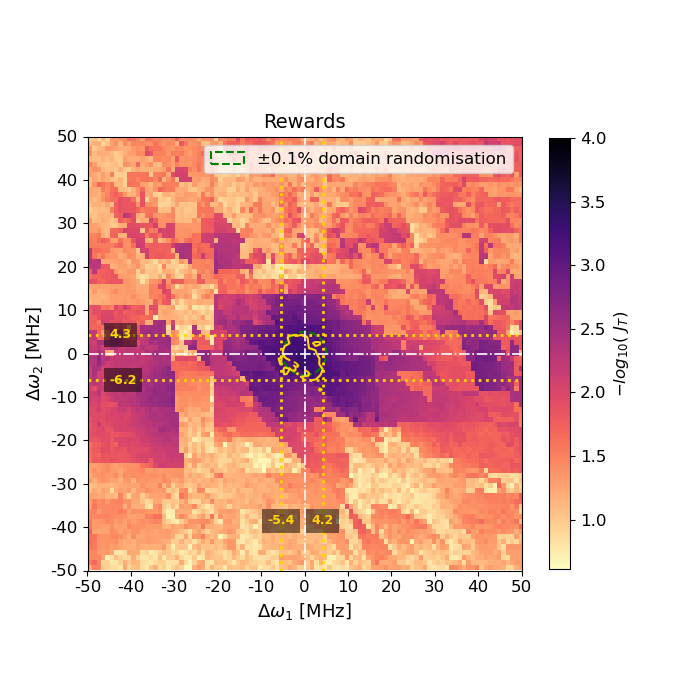

(101, 100)
(85, 100)
Figure save to: generalisation_wrd_concurs.pdf


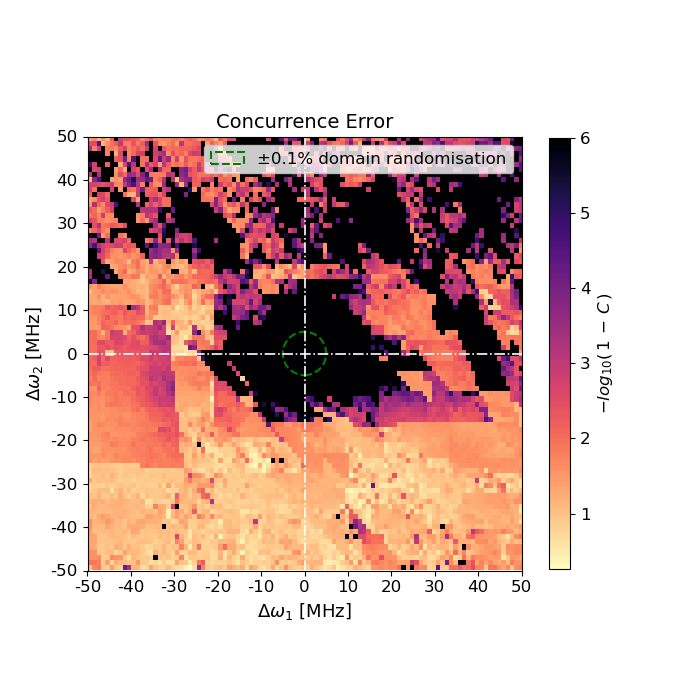

(101, 100)
(85, 100)
Figure save to: generalisation_wrd_unitars.pdf


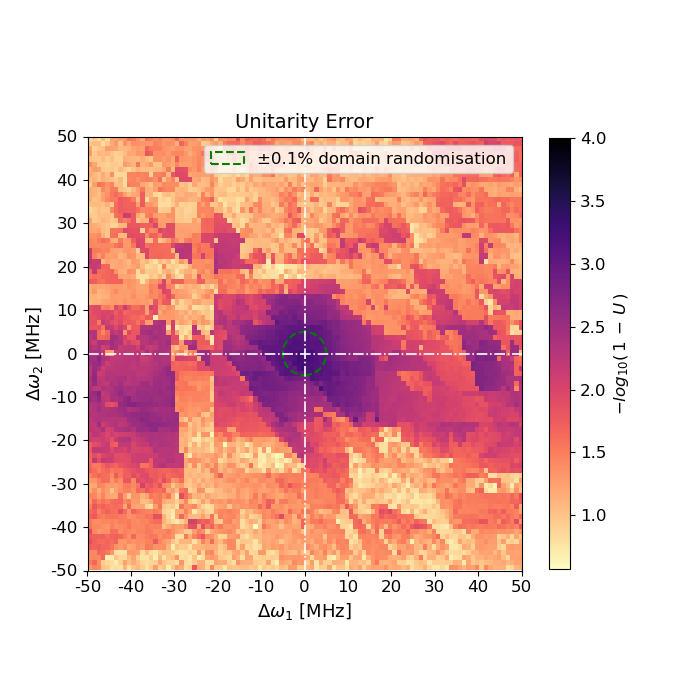

In [287]:
for slug, title, cbar_lbl, data, log_norm, a_min in zip( \
        ('rews', 'concurs', 'unitars'),
        ('Rewards', 'Concurrence Error', 'Unitarity Error'),
        ('$-log_{10}(\,\,J_T)$', '$-log_{10}(\,1\,-\,C\,)$', '$-log_{10}(\,1\,-\,U\,)$'),
        (best_reward_global, np.subtract(1, best_concur_global), np.subtract(1, best_unitar_global)),
        (False, False, False), 
        (0, 1e-6, 1e-4) \
    ):
        
    data = np.clip(data, a_min=a_min, a_max=np.inf)
    if 'rews' not in slug:
        data = -np.log10(data)

    if 'wrd' in save_name:
        data = data.T

    crop_data = data.copy()
    print(crop_data.shape)
    crop_data = crop_data[ytick_min:ytick_max]
    print(crop_data.shape)
    
    
    if log_norm:
        norm = LogNorm(vmin=a_min, vmax=1)
    else:
        vmax = 4 if a_min == 0 else -np.log10(a_min)
        vmin = np.min(crop_data)
        norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7,7))
    
    heatmap = ax.imshow(crop_data, 
                        cmap=cmap, 
                        norm=norm, 
                        origin='lower', 
                        extent=extent)
    cbar = fig.colorbar(heatmap, ax=ax, shrink=0.8, aspect=20)
    cbar.set_label(cbar_lbl, fontsize=fsz_ticks)#
    cbar.ax.tick_params(labelsize=fsz_ticks)

    # Add contour map for specific reward values
    if slug == 'rews':
        # Generate x and y coordinates for the contour plot based on the extent
        X = np.linspace(extent[0], extent[1], crop_data.shape[1])
        Y = np.linspace(extent[2], extent[3], crop_data.shape[0])
        
        # Store the contour object to add labels
        for i, (contour_level, lw, alpha, c, fsz) in enumerate(zip((3.2,),# 3.8),#, 2.5),
                                                                   (1.5, 1.3, 1.1),
                                                                   (1, 0.8, 0.6),
                                                                   ('gold', 'lime', 'w'),
                                                                   (10, 10, 8))):
            contour = ax.contour(X, Y, crop_data, levels=[contour_level], colors=c, linewidths=1.5)
            

            line_color = 'w'
            line_linestyle = ':'
            line_linewidth = 2.0
            line_alpha = 1.0
            label_color = 'w'
            label_fontsize = 9
            
            if contour_level == 3.2:
                label_color = 'gold'
                line_color = 'gold'
            else:
                label_color = 'lime'
                line_color = 'lime'
                
            # Extract coordinates and find relevant island min/max
            all_x_coords = []
            all_y_coords = []
            if contour.collections:
                for collection in contour.collections:
                    for path in collection.get_paths():
                        if path.vertices.size > 0: # Ensure there are vertices
                            x_coords = path.vertices[:, 0]
                            y_coords = path.vertices[:, 1]

                            _xc = x_coords.copy()
                            _xc = _xc[_xc > CONTOUR_MIN_LIM_X]
                            _xc = _xc[_xc < CONTOUR_MAX_LIM_X]

                            _yc = y_coords.copy()
                            _yc = _yc[_yc > CONTOUR_MIN_LIM_Y]
                            _yc = _yc[_yc < CONTOUR_MAX_LIM_Y]
                            all_x_coords.extend(_xc)
                            all_y_coords.extend(_yc)
    
            if all_x_coords and all_y_coords:
                min_x_3_8 = np.min(all_x_coords)
                max_x_3_8 = np.max(all_x_coords)
                equiv_y_max_x_3_8 = all_y_coords[np.argmin(all_x_coords)]
                min_y_3_8 = np.min(all_y_coords)
                max_y_3_8 = np.max(all_y_coords)

                labels = ax.clabel(contour, inline=True, fontsize=fsz, fmt='%1.1f', use_clabeltext=True)

                # Iterate through the returned Text objects and set their fontweight
                for label in labels:
                    label.set_fontweight('bold')
                
                # Add horizontal and vertical spanning lines for the 3.8 contour
                ax.axvline(min_x_3_8, color=line_color, linestyle=line_linestyle,
                           linewidth=line_linewidth, alpha=line_alpha)
                ax.axvline(max_x_3_8, color=line_color, linestyle=line_linestyle,
                           linewidth=line_linewidth, alpha=line_alpha)
                ax.axhline(min_y_3_8, color=line_color, linestyle=line_linestyle,
                           linewidth=line_linewidth, alpha=line_alpha)
                ax.axhline(max_y_3_8, color=line_color, linestyle=line_linestyle,
                           linewidth=line_linewidth, alpha=line_alpha)

                # Add labels for the min/max lines with Delta Omega notation
                # Position labels near the respective axis for clarity
                text_boxes = []
                text_boxes.append(ax.text(min_x_3_8, extent[2] + (extent[3] - extent[2]) * 0.1 * (i+1),
                        r'{:.1f}'.format(min_x_3_8),
                        color=label_color, fontsize=label_fontsize, ha='center', va='bottom', fontweight='bold', zorder=10))
                if contour_level == 3.8:
                    ha = 'left'
                else:
                    ha = 'center'
                    
                text_boxes.append(ax.text(max_x_3_8, extent[2] + (extent[3] - extent[2]) * 0.1 * (i+1),
                        r'{:.1f}'.format(max_x_3_8),
                        color=label_color, fontsize=label_fontsize, ha=ha, va='bottom', fontweight='bold', zorder=10))

                text_boxes.append(ax.text(extent[0] + (extent[1] - extent[0]) * 0.05 , min_y_3_8,
                        r'{:.1f}'.format(min_y_3_8),
                        color=label_color, fontsize=label_fontsize, ha='left', va='center', fontweight='bold', zorder=10))

                if contour_level == 3.8:
                    va = 'top'
                else:
                    va = 'center'
                text_boxes.append(ax.text(extent[0] + (extent[1] - extent[0]) * 0.05 , max_y_3_8,
                        r'{:.1f}'.format(max_y_3_8),
                        color=label_color, fontsize=label_fontsize, ha='left', va=va, fontweight='bold', zorder=10))
                for t in text_boxes:
                    t.set_bbox(dict(facecolor='k', alpha=0.5, edgecolor='None', zorder=5))

                

    ax.axhline(0.0, c=zero_line_c, lw=zero_line_lw, ls='-.')#, alpha=0.7)
    ax.axvline(0.0, c=zero_line_c, lw=zero_line_lw, ls='-.')#, alpha=0.7)

    if 'zoom' in save_name:
        ax.set_aspect(2.12)

    # if 'wrd' in save_name:
    #     ax.set_aspect(2.1)

    # ax.set_xlim((-ABS_MAX_OMEGA, ABS_MAX_OMEGA))
    # ax.set_ylim((-ABS_MAX_OMEGA, ABS_MAX_OMEGA))

    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    
    ax.set_title(title, fontsize=fsz_title)
    ax.set_xticklabels(xtick_labels, fontsize=fsz_ticks)
    ax.set_yticklabels(ytick_labels, fontsize=fsz_ticks) # dirty harry fix
    ax.set_xlabel(r'$\Delta ω_1$ [MHz]', fontsize=fsz_axlbl)
    ax.set_ylabel(r'$\Delta ω_2$ [MHz]', fontsize=fsz_axlbl)

    if 'wrd' in load_name:
        circle_patch = mpl.patches.Circle(xy=(0,0), radius=5, facecolor='None', edgecolor='g', lw=1.5, ls='dashed')
        ax.add_patch(circle_patch)
        ax.legend([circle_patch], ['±0.1% domain randomisation'], prop=dict(size=fsz_ticks), frameon=True)


    # fig.tight_layout()
    save_path = save_name + '_' + slug + '.pdf'
    # fig.tight_layout()
    fig.savefig(save_path, bbox_inches='tight')
    print(f'Figure save to: {save_path}')
    plt.show()

In [244]:
%matplotlib widget

# Misc

In [115]:
obs = env.reset()[0]
term = False
trunc = False
idx = 0
rews = []
if verbose >= 0:
    pbar= tqdm(total=env.pulse_length)
    
prev_amp = 0.
pulse = [prev_amp]
info = None
max_t = 50.

while not term:
    a = model.predict(obs, deterministic=True)[0]

    idx += 1
    obs, r, term, trunc, info = env.step(a, can_early_term=(not no_term))

    a_trans = env.transform_action(a)
    a_denorm = env.denorm_action(a_trans).reshape(env.N_TIME_STEPS)
    amp_abs_denorm = prev_amp + np.cumsum(a_denorm)
    prev_amp = amp_abs_denorm[-1]
    pulse.extend(amp_abs_denorm)

    rews.append(r)
    if verbose >= 0:
        pbar.update(env.N_TIME_STEPS)

    if idx * env.dt >= max_t:
        break

final_realised_gate = info['realised_gate']

# Prepare time-axis and pulse amplitude data for plotting
infidelities = 1 - np.array(env.fidelities)

n_steps_coarse = len(infidelities)
tlist_coarse = np.arange(n_steps_coarse) * env.dt * env.N_TIME_STEPS

n_steps_fine = len(pulse)
tlist_fine = np.arange(n_steps_fine) * env.dt

idx_best_coarse = np.argmax(rews)
t_best = tlist_coarse[idx_best_coarse]
idx_best_fine = np.argmin(np.abs(np.subtract(tlist_fine, t_best)))

print(f"n_steps_coarse={n_steps_coarse}, idx_best_coarse={idx_best_coarse}, idx_best_fine={idx_best_fine}")

if clip_best:
    ep_len_coarse = idx_best_coarse + 1
    ep_len_fine = idx_best_fine + 1
else:
    ep_len_coarse = n_steps_coarse
    ep_len_fine = n_steps_fine

tlist_coarse = tlist_coarse[:ep_len_coarse]
tlist_fine = tlist_fine[:ep_len_fine]
pulse = pulse[:ep_len_fine]
infidelities = infidelities[:ep_len_coarse]
concurrences = np.array(env.concurrences[:ep_len_coarse])
unitarities = np.array(env.unitarities[:ep_len_coarse])
#
# data = dict(concurrences=concurrences,
#             unitarities=unitarities,
#             infidelities=infidelities,
#             tlist_coarse=tlist_coarse,)
# pd.DataFrame.from_dict(data).to_csv('pulse_metrics_for_mkrauss.csv', index=False)
#
# exit(23)

max_fid = env.fidelities[idx_best_coarse] * 100.
idx_min_infidelity = np.argmin(infidelities)
idx_max_concurrence = np.argmax(concurrences)
idx_max_unitarity = np.argmax(unitarities)
metrics_str = lambda j: f'Rew={rews[j]:.2f} => C={concurrences[j]:.4f}; U={unitarities[j]:.4f}; (1-F)={infidelities[j]:.4f} @ T={tlist_coarse[j]:.2f}ns; PL={j+1:d}'
title = (f'Best Reward: {metrics_str(idx_best_coarse)}\n'
         f'Best Concurrence: {metrics_str(idx_max_concurrence)}\n'
         f'Best Unitarity: {metrics_str(idx_max_unitarity)}\n'
         f'Best Fidelity: {metrics_str(idx_min_infidelity)}'
         )
if verbose > 0:
    print(f'Model: {model_zip}; Ep: {i}')
    print(title + '\n')

NameError: name 'env' is not defined